In [1]:
!pip install networkx

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [12]:
!pip install seaborn

     |████████████████████████████████| 293 kB 928 kB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
import networkx as nx

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from spektral.data import Dataset, Graph
from spektral.layers import GraphSageConv
from spektral.utils import normalized_adjacency
from spektral.models.gcn import GCN 

from scipy import sparse
from scipy.special import softmax

from sklearn.model_selection import train_test_split


## Function to plotting a graph

In [2]:
def plot_graph(G, communities=None):
    pos = nx.spring_layout(G, seed=42)
    
    if communities is not None:
        # Assign colors to nodes based on their communities
        colors = ['orange' if community == 0 else 'skyblue' for community in communities]
    else:
        colors = 'red'

    nx.draw(G, pos, node_color=colors, with_labels=True)
    plt.show()



## CSBM Generation - Caso base (Harpo)

In [2]:
def generate_synthetic_graph_csbm(n_nodes, n_communities, n_features, edge_prob_matrix, node_feature_means,\
                                  feature_cov_matrix=None):
    # Assign nodes to communities
    communities = np.random.randint(0, n_communities, n_nodes)

    # Generate node features
    if feature_cov_matrix is None:
        feature_cov_matrix = np.eye(n_features)
    features = np.zeros((n_nodes, n_features))
    for k in range(n_communities):
        nodes_in_community = np.where(communities == k)[0]
        features[nodes_in_community] = np.random.multivariate_normal(node_feature_means[k], feature_cov_matrix,\
                                                                     len(nodes_in_community))

    # Compute community membership probabilities based on node features
    community_membership_probs = softmax(features @ node_feature_means.T, axis=1)

    # Generate edges based on community membership probabilities
    adjacency_matrix = np.zeros((n_nodes, n_nodes))
    for i in range(n_nodes):
        for j in range(i, n_nodes):
            if i == j:
                continue
            community_i = communities[i]
            community_j = communities[j]
            edge_prob = edge_prob_matrix[community_i, community_j] * community_membership_probs[i, community_j] * community_membership_probs[j, community_i]
            adjacency_matrix[i, j] = adjacency_matrix[j, i] = np.random.binomial(1, edge_prob)

    labels = tf.keras.utils.to_categorical(communities)
    adjacency_matrix = sparse.csr_matrix(adjacency_matrix)
    return Graph(x=features, a=adjacency_matrix, y=labels)

    #return adjacency_matrix, features, communities


### Class for generating synthetic datasets

In [3]:
class SyntheticDataset(Dataset):
    def __init__(self, graphs=None, **kwargs):
        self.graphs = graphs
        super().__init__(**kwargs)

    def read(self):
        return self.graphs

### Generating graphs

In [4]:
n_graphs = 2
n_nodes = 100
n_features = 2
n_classes = 2
# Probability matrix for edges between communities
edge_prob_matrix = np.array([
    [0.8, 0.2],
    [0.3, 0.7]
])

# Node feature means for each community
node_feature_means = np.array([
    [2, 1], #, 0, 0, 0],
    [1, 2] #, 0, 0, 0]
])


graphs = [generate_synthetic_graph_csbm(n_nodes, n_classes, n_features, edge_prob_matrix, node_feature_means, feature_cov_matrix=None) for _ in range(n_graphs)]



In [11]:
graphs[0].x

array([[-0.11314391,  2.59832743],
       [ 0.72215642,  2.32680625],
       [ 1.46856775,  2.59570741],
       [ 1.88060787,  1.83198902],
       [ 3.59312993, -0.38855247],
       [ 2.04438033,  0.2138031 ],
       [ 2.10505848,  2.92369742],
       [ 0.41843294,  2.22526068],
       [ 0.10204065,  2.51528524],
       [ 0.754335  ,  2.06086559],
       [ 1.31629789,  0.60784111],
       [ 1.8675183 ,  1.64334014],
       [ 1.96834265,  1.36377919],
       [ 1.81108084,  2.58984298],
       [ 0.43828609,  2.71955877],
       [ 1.66957493,  0.91812755],
       [ 2.66952885,  1.55274314],
       [ 2.1835369 ,  1.17693845],
       [ 1.81235184,  0.15207403],
       [ 2.48020599,  1.94806329],
       [ 0.3975631 ,  0.51989724],
       [ 0.93455903,  0.16898339],
       [ 1.47719064, -0.04502028],
       [ 0.81270944,  2.87558552],
       [ 0.8500644 , -0.60656989],
       [ 1.3830919 ,  2.31348075],
       [ 1.15354555,  2.31433863],
       [ 1.35561222,  1.98953825],
       [ 2.19738194,

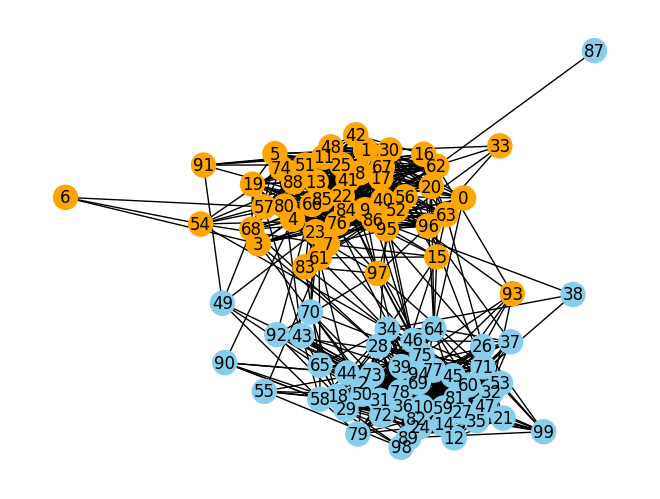

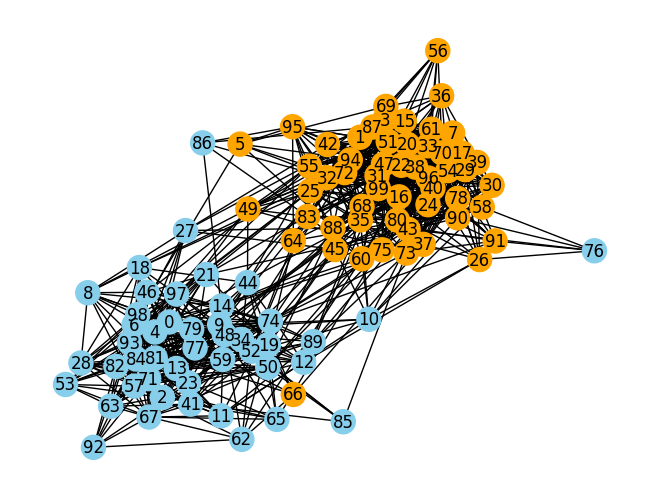

In [9]:
for G in graphs:
    nxG = nx.from_numpy_array(G.a)
    labels = np.argmax(G.y,axis=1)
    plot_graph(nxG,labels)

In [5]:
train_graphs, test_graphs = train_test_split(graphs, test_size=0.5, random_state=42)
train_dataset = SyntheticDataset(train_graphs)
test_dataset = SyntheticDataset(test_graphs)

In [6]:
train_graphs

[Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2)]

In [7]:
train_dataset

SyntheticDataset(n_graphs=1)

In [11]:
from spektral.data import BatchLoader,DisjointLoader,SingleLoader
batch_size = 1

# Create data loaders for training and testing data
#train_loader = BatchLoader(train_dataset, batch_size=batch_size)
#test_loader = BatchLoader(test_dataset, batch_size=batch_size)

train_loader = SingleLoader(train_dataset)
test_loader = SingleLoader(test_dataset)


In [12]:
model = GCN(n_labels=n_classes,channels=16,l2_reg=1.0000,dropout_rate=0)

In [13]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss="binary_crossentropy", metrics=["accuracy"])

# Define early stopping to prevent overfitting
es_callback = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_loader.load(),
    steps_per_epoch=train_loader.steps_per_epoch,
    epochs=100,
    validation_data=test_loader.load(),
    validation_steps=test_loader.steps_per_epoch#,
    #callbacks=[es_callback],
)


Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 130.6972 - accuracy: 0.5100 - val_loss: 132.4277 - val_accuracy: 0.4600
Epoch 2/100
1/1 [==============================] - 0s 12ms/step - loss: 105.7305 - accuracy: 0.5100 - val_loss: 109.5807 - val_accuracy: 0.4600
Epoch 3/100
1/1 [==============================] - 0s 12ms/step - loss: 82.3160 - accuracy: 0.5100 - val_loss: 88.1585 - val_accuracy: 0.4600
Epoch 4/100
1/1 [==============================] - 0s 12ms/step - loss: 63.4097 - accuracy: 0.5100 - val_loss: 70.0661 - val_accuracy: 0.4600
Epoch 5/100
1/1 [==============================] - 0s 12ms/step - loss: 50.7384 - accuracy: 0.5100 - val_loss: 53.0303 - val_accuracy: 0.4600
Epoch 6/100
1/1 [==============================] - 0s 12ms/step - loss: 38.6293 - accuracy: 0.5100 - val_loss: 36.3030 - val_accuracy: 0.5500
Epoch 7/100
1/1 [==============================] - 0s 12ms/step - loss: 26.6919 - accuracy: 0.6800 - val_loss: 19.7842 - val_accuracy: 0.9300
Epoc

1/1 [==============================] - 0s 15ms/step - loss: 2.6557 - accuracy: 0.9700 - val_loss: 4.4182 - val_accuracy: 0.9500
Epoch 60/100
1/1 [==============================] - 0s 14ms/step - loss: 2.6330 - accuracy: 0.9700 - val_loss: 4.5007 - val_accuracy: 0.9300
Epoch 61/100
1/1 [==============================] - 0s 13ms/step - loss: 2.6257 - accuracy: 0.9600 - val_loss: 4.5541 - val_accuracy: 0.9300
Epoch 62/100
1/1 [==============================] - 0s 13ms/step - loss: 2.6255 - accuracy: 0.9600 - val_loss: 4.5437 - val_accuracy: 0.9300
Epoch 63/100
1/1 [==============================] - 0s 13ms/step - loss: 2.6121 - accuracy: 0.9600 - val_loss: 4.4872 - val_accuracy: 0.9300
Epoch 64/100
1/1 [==============================] - 0s 13ms/step - loss: 2.5875 - accuracy: 0.9600 - val_loss: 4.4032 - val_accuracy: 0.9300
Epoch 65/100
1/1 [==============================] - 0s 14ms/step - loss: 2.5590 - accuracy: 0.9600 - val_loss: 4.3183 - val_accuracy: 0.9500
Epoch 66/100
1/1 [========

In [14]:
import pandas as pd
res=pd.DataFrame(history.history)

# Add row index as a new column
res.reset_index(inplace=True)

# Rename the new column to 'row_id'
res.rename(columns={'index': 'epoch'}, inplace=True)
res

,epoch,loss,accuracy,val_loss,val_accuracy
0,0,130.697189,0.51,132.427719,0.46
1,1,105.730476,0.51,109.580719,0.46
2,2,82.316048,0.51,88.158539,0.46
3,3,63.409683,0.51,70.066086,0.46
4,4,50.738373,0.51,53.030251,0.46
...,...,...,...,...,...
95,95,2.085830,0.97,3.539142,0.95
96,96,2.072385,0.97,3.511839,0.95
97,97,2.058289,0.97,3.480167,0.95
98,98,2.044140,0.97,3.448022,0.95


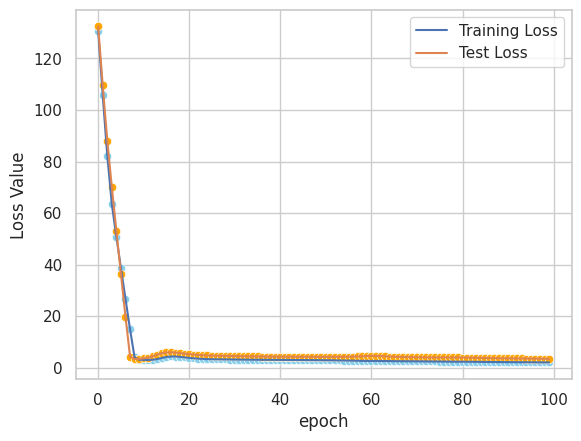

In [15]:
history.history['accuracy']

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
line1 = sns.lineplot(x="epoch", y='loss', data=res, label='Training Loss')
line2 = sns.lineplot(x="epoch", y='val_loss', data=res, label='Test Loss')


# Add points to each observation
scatter1 = sns.scatterplot(x="epoch", y='loss', data=res, marker='o', color='skyblue')
scatter2 = sns.scatterplot(x="epoch", y='val_loss', data=res, marker='o', color='orange')

# Change the y-axis label
plt.ylabel("Loss Value")

# Create a legend for the lines
plt.legend()

# Show the plot
plt.show()



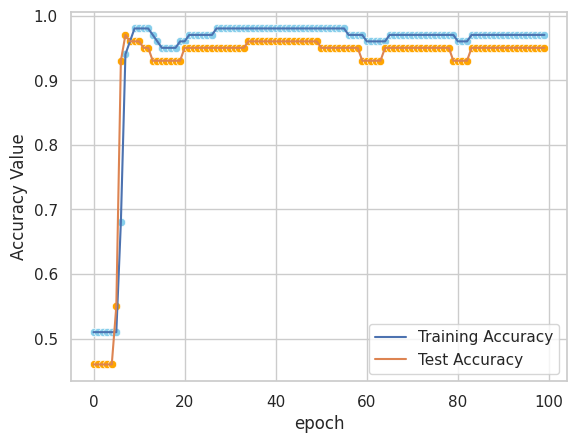

In [16]:
sns.set_theme(style="whitegrid")
line1 = sns.lineplot(x="epoch", y="accuracy", data=res, label='Training Accuracy')
line2 = sns.lineplot(x="epoch", y="val_accuracy", data=res, label='Test Accuracy')

# Add points to each observation
scatter1 = sns.scatterplot(x="epoch", y="accuracy", data=res, marker='o', color='skyblue')
scatter2 = sns.scatterplot(x="epoch", y="val_accuracy", data=res, marker='o', color='orange')

# Change the y-axis label
plt.ylabel("Accuracy Value")

# Create a legend for the lines
plt.legend()

# Show the plot
plt.show()

In [17]:
predictions = []
targets = []
step = 0
while step < test_loader.steps_per_epoch:
        step += 1
        inputs, target = test_loader.__next__()
        pred = model(inputs, training=False)
        predictions.append(pred)
        targets.append(target)
    
predictions = np.vstack(predictions)
    
targets = np.vstack(targets)
# Post-process the predictions if necessary (e.g., convert probabilities to class labels)
predicted_values = np.argmax(predictions, axis=1)
true_labels = np.argmax(targets,axis =1 )

In [18]:
from sklearn.metrics import confusion_matrix,roc_auc_score,accuracy_score
conf_mat = confusion_matrix(predicted_values, true_labels)
print(conf_mat)


[[53  4]
 [ 1 42]]


In [19]:
auc_score = roc_auc_score(true_labels, predicted_values)
accuracy_score = accuracy_score(true_labels, predicted_values)

print("AUC Score:", auc_score)
print("Accuracy Score:", accuracy_score)

AUC Score: 0.9472624798711756
Accuracy Score: 0.95
